# Can shared vocabulary fix consensus blind spots? (T8, Part 1 demo)

This notebook demonstrates the **evaluation** `art_BvAL_KZTZuw8` (T8, iteration 4). It is CPU only and makes no LLM calls.

**Setting.** We score NL→FOL candidate formalizations *without a gold formula*. The signal is **cross-family consensus**:
a candidate from one model family is *endorsed* when more than half of its peers, which are formalizations of the same
sentence by *other* model families, agree with it. Endorsement is a binary faithfulness detector, and its errors
split exactly into two parts (balanced-accuracy identity `AUROC_b = 1 − (e + d)/2`):

* **e**: error-endorsement, `P(endorsed | ERROR)`. Wrong candidates that the peers agree with.
* **d**: correct-divergence, `P(not endorsed | CORRECT)`. Correct candidates that the peers fail to endorse.

**Question.** How much of **d** comes from *vocabulary* (different predicate names or decompositions of one concept)?
That part is what shared vocabulary could fix. The rest is *irreducible* disagreement. Every candidate–peer pair
gets one class: `EXACT` (z3-equivalent as written), `NAME_ONLY` (equivalent after normalising predicate
spelling), `ALIGN_ONLY` (equivalent after predicate alignment), `VOCAB` (equivalent only under the NF/HYB
vocabulary-resolving checks) or `IRREDUCIBLE`. Counting rules then turn different sets of classes into
"agreement":

| rule | a peer agrees when… |
|---|---|
| `R_exact` | EXACT |
| `R_align` | EXACT or ALIGN (= END_MAJ, the eval-2 baseline) |
| `R_name` | R_align or NAME_ONLY |
| `R_liberal` | R_name or VOCAB (upper bound: every VOCAB pair counts) |
| `R_point_MC` / `R_point_label` | R_name plus each VOCAB pair accepted with the pre-registered probability. `_label` uses the peer's gold label where it has one (the pre-registered **d_floor prediction**) |
| `R_oracle` | oracle: the peer is labelled the *same way* (CORRECT, or ERROR with the same error-op class) |

**What this notebook runs.** `eval.py` is a thin orchestrator that runs `src/t8_*.py` in sequence. This demo replays
the core of `src/t8_part1.py` (the counting rules, the e/d decomposition with sentence-cluster bootstrap CIs, pair-class
shares, the specificity placebo and `c_vres`) **unchanged** on a curated subset of 10 sentences (100 candidate rows,
1,024 peer pairs). The expensive upstream steps are precomputed flags in the data file: the z3 equivalence matrix from
eval 2, the NAME_ONLY z3 checks and the NF/HYB joins from exp 8. The GEE slopes are omitted because they need eval-2's
`mechanism.gee_fit`.

> E is **development data**, so nothing here is confirmation. The subset was chosen to over-represent `VOCAB` pairs, so
> its class shares and e/d values are *illustrative*. The full-run numbers (2,672 rows, 25,358 pairs) are printed next
> to the demo numbers at the end.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The import block of `src/t8_part1.py`, followed by the imports that eval-2's `stats.py` needs (vendored below) and
matplotlib for the final figure. The eval-2 modules `consensus_mx`, `mechanism`, `frame`, `t8_classes` and `pairwise`
live in other workspaces of the pipeline. Their outputs are already in the data file.

In [2]:
import hashlib
import json
import multiprocessing as mp
import os
import sys
import time
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

os.environ["PYTHONHASHSEED"] = "0"
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402

# needed by the vendored eval-2 stats helpers + the notebook's own figures
import types
from scipy.stats import rankdata
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data loading
The data file is loaded from GitHub, with a local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_Jhw6i0bFXdo3/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
print({k: meta[k] for k in ("n_sentences", "n_rows", "n_pairs", "p_accept_vocab")})

{'n_sentences': 10, 'n_rows': 100, 'n_pairs': 1024, 'p_accept_vocab': 0.6123595505617978}


## Config
These are the constants of `src/t8_part1.py`. `N_MC` sets the Monte-Carlo draws for the probabilistic VOCAB rules, `B` the
sentence-cluster bootstrap replicates and `N_DRAW_PLACEBO` the random-pair placebo draws. The original values are
`N_MC = 500`, `B = 2000` and `n_draw = 200`. `P_ACC` is the pre-registered VOCAB acceptance probability, read from
`prereg_d_split.json` (`vocab_discount.accept_prob`) and stored in the data file.

In [5]:
POOL3 = ("deepseek", "microsoft", "openai")   # matched 3-family peer pool (PRIMARY); "9fam" = all nine families
N_MC = 500             # original: 500
B = 2000                # original: 2000
N_DRAW_PLACEBO = 200    # original: 200 (placebo(..., n_draw=200))
TARGET = {"e": 0.124, "d": 0.537, "auroc_c_exact": 0.748, "auroc_c_align": 0.784}
RULES_DET = ["R_exact", "R_align", "R_name", "R_liberal", "R_oracle", "R_oracle_labdenom"]
RULES_MC = ["R_point_MC", "R_point_label"]
RULES = RULES_DET + RULES_MC
P_ACC = float(meta["p_accept_vocab"])        # pre-registered VOCAB acceptance probability (0.612)
print("N_MC", N_MC, "B", B, "N_DRAW_PLACEBO", N_DRAW_PLACEBO, "P_ACC", round(P_ACC, 4))

N_MC 500 B 2000 N_DRAW_PLACEBO 200 P_ACC 0.6124


## Vendored eval-2 statistics (`src/stats.py`, `src/mechanism.py`)
T8 imports these from the eval-2 workspace **unchanged** (code sha `dd73975642f428cc`), so they are copied here verbatim:
tie-aware AUROC, stratified AUROC, the percentile CI, bootstrap-weighted AUROCs, the sentence-cluster bootstrap
`SentBoot` and `ed_decomposition`, which asserts the identity `AUROC_b = 1 − (e+d)/2`. A small namespace `MC` stands in for
`import mechanism as MC`, so the Part-1 code below runs as written.

In [6]:
B_DEFAULT = 2000


def auc(y, s) -> float:
    """Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    """Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified')."""
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement)."""

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        """(B, n_rows[mask]) weight matrix."""
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]


MIN_ROWS, MIN_SENT = 30, 10


def ed_decomposition(y, endorsed) -> dict:
    """y: 1 = ERROR, 0 = CORRECT; endorsed: 1 = the cross-family peer rule endorses the candidate.
    Returns e = P(endorsed | ERROR) (error-endorsement), d = P(not endorsed | CORRECT) (correct-divergence) and
    AUROC_b of b = 1 - endorsed, asserting the bookkeeping identity AUROC_b = 1 - (e + d)/2 (balanced accuracy)."""
    y = np.asarray(y, int)
    en = np.asarray(endorsed, int)
    e = float(en[y == 1].mean())
    d = float((1 - en[y == 0]).mean())
    a = auc(y, 1 - en)
    assert abs(a - (1 - (e + d) / 2)) < 1e-12, (a, e, d)
    return {"n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum()), "e": e, "d": d, "auroc_b": a}


# stand-in for `import mechanism as MC` (only the names Part 1 uses without GEE)
MC = types.SimpleNamespace(MIN_ROWS=MIN_ROWS, MIN_SENT=MIN_SENT, ed_decomposition=ed_decomposition)

## Build `P` (candidate rows) and `Q` (candidate × family-disjoint peer pairs)
In the original, `load()` and `build_pairs()` rebuild these tables from the eval-2 equivalence matrix
(`pairwise_classes_E.jsonl`). `add_name_only()` then runs the NAME_ONLY z3 checks and `add_pairs_E()` joins exp 8's NF/HYB
verdicts. The data file already holds each row's flags (`f_exact`, `f_align`, `f_name`, `f_vocab_raw`), so here we
only unpack them into the same two DataFrames. `classify()` is the original function. It re-derives each pair's class
from the four flags using the precedence EXACT > NAME_ONLY > ALIGN_ONLY > VOCAB > IRREDUCIBLE. We then check the result
against the stored class.

In [7]:
rows = data["datasets"][0]["examples"]
P = pd.DataFrame([{k: v for k, v in r.items() if k != "pairs"} for r in rows])
P["y_AB"] = P.y_AB.astype(float)
P["long"] = P["long"].astype(bool)
Q = pd.DataFrame([{"sentence_id": r["sentence_id"], "cand": r["row_key"], "stratum": r["stratum"], **p}
                  for r in rows for p in r["pairs"]])
Q["peer_y"] = Q.peer_y.astype(float)          # NaN = unlabelled peer
cls_stored = Q.pop("cls")
Q = Q.drop(columns=["f_vocab_extra", "in_pool3"])   # recomputed by classify()


def classify(Q: pd.DataFrame) -> None:
    Q["cls"] = np.select([Q.f_exact, Q.f_name, Q.f_align, Q.f_vocab_raw],
                         ["EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB"], "IRREDUCIBLE")
    Q["f_vocab_extra"] = Q.cls == "VOCAB"
    Q["in_pool3"] = Q.peer_family.isin(POOL3)


classify(Q)
assert (Q.cls.values == cls_stored.values).all(), "pair classes differ from the stored run"
print(f"P {len(P)} rows ({int(P.y_AB.sum())} ERROR / {int((1 - P.y_AB).sum())} CORRECT) in {P.sentence_id.nunique()} sentences; "
      f"Q {len(Q)} pairs")
print("pair classes (9-family):", Q.cls.value_counts().to_dict())
print("pair classes (3-pool):  ", Q[Q.in_pool3].cls.value_counts().to_dict())
P[["sentence_id", "stratum", "words", "n_conditions", "family_vendor", "candidate_fol", "y_AB"]].head(8)

P 100 rows (56 ERROR / 44 CORRECT) in 10 sentences; Q 1024 pairs
pair classes (9-family): {'IRREDUCIBLE': 590, 'EXACT': 160, 'VOCAB': 147, 'ALIGN_ONLY': 127}
pair classes (3-pool):   {'IRREDUCIBLE': 160, 'ALIGN_ONLY': 55, 'EXACT': 55, 'VOCAB': 44}


,sentence_id,stratum,words,n_conditions,family_vendor,candidate_fol,y_AB
0,0097807c718e,L20,23,3,openai,"∀x (Animal(x) ∧ PrimarilyFeedsOn(x, otherAnima...",0.0
1,0097807c718e,L20,23,3,meta,∀x (Carnivore(x) ↔ (PrimarilyFeedsOnOtherAnima...,1.0
2,0097807c718e,L20,23,3,meta,∀x (Animal(x) → (Carnivore(x) ↔ (PrimarilyFeed...,1.0
3,0097807c718e,L20,23,3,mistral,"∀x (Animal(x) ∧ PrimarilyFeedsOn(x, otherAnima...",0.0
4,0097807c718e,L20,23,3,deepseek,"∀x (Animal(x) ∧ PrimarilyFeedsOn(x, otherAnima...",0.0
5,0097807c718e,L20,23,3,google,"∀x (Animal(x) ↔ (PrimarilyFeedsOn(x, animals) ...",1.0
6,0097807c718e,L20,23,3,microsoft,"∀x (Animal(x) ∧ PrimarilyFeedsOn(x, otherAnima...",0.0
7,0097807c718e,L20,23,3,openai,"∀x ((Animal(x) ∧ PrimarilyFeedsOn(x, otherAnim...",0.0


## Counting rules: deterministic endorsement (`endorse_det`)
For each candidate, the function counts the peers in the pool (`n`) and the peers that agree under each rule (`k`). The
candidate is endorsed when `k > n/2`, which is a strict majority. `R_oracle` uses the gold labels: a CORRECT candidate's
peer agrees if it is also CORRECT, and an ERROR candidate's peer agrees if it is an ERROR with the same error-op class.
`R_oracle_labdenom` uses the same test but counts only labelled peers in the denominator. The code is verbatim from
`t8_part1.py`.

In [8]:
def endorse_det(Q: pd.DataFrame, P: pd.DataFrame, pool: str) -> tuple[dict, np.ndarray]:
    """Deterministic endorsement per rule for every P row (NaN when the pool has no rows)."""
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    idx = {rk: i for i, rk in enumerate(P.row_key)}
    ci_ = q.cand.map(idx).values
    n = np.bincount(ci_, minlength=len(P)).astype(float)
    y = P.y_AB.values.astype(int)
    cand_opc = P.row_key.map(dict(zip(Q.cand, Q.cand_opc))).values
    agree = {
        "R_exact": q.f_exact.values, "R_align": q.f_align.values, "R_name": (q.f_align | q.f_name).values,
        "R_liberal": (q.f_align | q.f_name | q.f_vocab_raw).values}
    peer_y = q.peer_y.values
    cy = y[ci_]
    lab_agree = np.where(cy == 0, peer_y == 0, (peer_y == 1) & (q.peer_opc.values == cand_opc[ci_]))
    agree["R_oracle"] = lab_agree
    labelled = np.array([v in (0, 1) for v in peer_y])
    out = {}
    with np.errstate(invalid="ignore", divide="ignore"):
        for r, a in agree.items():
            k = np.bincount(ci_, weights=a.astype(float), minlength=len(P))
            out[r] = np.where(n > 0, (k > n / 2).astype(float), np.nan)
        k = np.bincount(ci_, weights=lab_agree.astype(float), minlength=len(P))
        nl = np.bincount(ci_, weights=labelled.astype(float), minlength=len(P))
        out["R_oracle_labdenom"] = np.where(nl > 0, (k > nl / 2).astype(float), np.nan)
        out["_n"] = n
        out["_agree_liberal"] = np.bincount(ci_, weights=agree["R_liberal"].astype(float), minlength=len(P))
        out["_agree_align"] = np.bincount(ci_, weights=agree["R_align"].astype(float), minlength=len(P))
    return out, ci_

## Probabilistic VOCAB rules (`endorse_mc`)
`R_point_MC` accepts each VOCAB pair with the pre-registered probability `P_ACC`. **`R_point_label`** is the
pre-registered *d_floor prediction*. It uses the peer's gold label where one exists (accept only if the labels agree
as in `R_oracle`) and falls back to `P_ACC` for unlabelled peers. Both are drawn `N_MC` times. The code is verbatim.

In [9]:
def endorse_mc(Q: pd.DataFrame, P: pd.DataFrame, pool: str, p_acc: float, seed: int = 0) -> dict:
    """(N_MC, n_rows) endorsement draws for R_point_MC and R_point_label."""
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    idx = {rk: i for i, rk in enumerate(P.row_key)}
    ci_ = q.cand.map(idx).values
    n = np.bincount(ci_, minlength=len(P)).astype(float)
    base = np.bincount(ci_, weights=(q.f_align | q.f_name).values.astype(float), minlength=len(P))
    vx = q.f_vocab_extra.values
    y = P.y_AB.values.astype(int)
    cy = y[ci_]
    peer_y = q.peer_y.values
    cand_opc = P.row_key.map(dict(zip(Q.cand, Q.cand_opc))).values[ci_]
    unl = np.array([v not in (0, 1) for v in peer_y])
    acc_lab = np.where(cy == 0, peer_y == 0, (peer_y == 1) & (q.peer_opc.values == cand_opc))
    p_label = np.where(unl, p_acc, acc_lab.astype(float))
    rng = np.random.default_rng(seed)
    vi = np.where(vx)[0]
    U = rng.random((N_MC, len(vi)))
    out = {}
    for name, prob in (("R_point_MC", np.full(len(vi), p_acc)), ("R_point_label", p_label[vi])):
        acc = (U < prob[None, :]).astype(float)
        K = np.zeros((N_MC, len(P)))
        np.add.at(K.T, ci_[vi], acc.T)
        with np.errstate(invalid="ignore"):
            out[name] = np.where(n[None, :] > 0, ((base[None, :] + K) > n[None, :] / 2).astype(float), np.nan)
    return out

## e / d with sentence-cluster bootstrap CIs (`ed_ci`, `cut_labels`, `rule_tables`)
For each rule and each cut (ALL, words tercile, number-of-conditions bin, stratum, and the long pool L25+L20+EXC), the
code reports **e**, **d**, `AUROC_b` and 95% percentile CIs from `B` sentence-cluster bootstrap replicates. For the MC
rules, replicate `b` uses draw `b % N_MC`, so each band combines bootstrap and MC variance. `testable_*` marks cells
with at least 30 rows and 10 sentences. On this 10-sentence demo no cell passes. The code is verbatim.

In [10]:
def ed_ci(y, en, W) -> dict:
    """e, d, AUROC_b with sentence-cluster CIs. en: (n,) binary or (N_MC, n) draws (combined band: replicate b uses
    draw b % N_MC)."""
    y = np.asarray(y, int)
    if en.ndim == 1:
        e = float(en[y == 1].mean()) if (y == 1).any() else np.nan
        d = float(1 - en[y == 0].mean()) if (y == 0).any() else np.nan
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W @ (en * y)) / (W @ y)
            db = (W @ ((1 - en) * (1 - y))) / (W @ (1 - y))
        rec = {"e": e, "d": d}
    else:
        e = float(np.nanmean(en[:, y == 1].mean(1))) if (y == 1).any() else np.nan
        d = float(np.nanmean(1 - en[:, y == 0].mean(1))) if (y == 0).any() else np.nan
        M = en[np.arange(W.shape[0]) % en.shape[0]]
        with np.errstate(invalid="ignore", divide="ignore"):
            eb = (W * M * y).sum(1) / (W @ y)
            db = (W * (1 - M) * (1 - y)).sum(1) / (W @ (1 - y))
        rec = {"e": e, "d": d, "mc_band_e": [float(np.percentile(en[:, y == 1].mean(1), 2.5)), float(np.percentile(en[:, y == 1].mean(1), 97.5))] if (y == 1).any() else [None, None],
               "mc_band_d": [float(np.percentile(1 - en[:, y == 0].mean(1), 2.5)), float(np.percentile(1 - en[:, y == 0].mean(1), 97.5))] if (y == 0).any() else [None, None]}
    rec.update({"auroc_b": 1 - (e + d) / 2, "e_ci": ci(eb), "d_ci": ci(db), "auroc_b_ci": ci(1 - (eb + db) / 2),
                "n_err": int((y == 1).sum()), "n_cor": int((y == 0).sum())})
    return rec


def cut_labels(P: pd.DataFrame) -> dict:
    return {"ALL": np.array(["ALL"] * len(P), object), "words_tercile": P.words_t.values, "ncond_bin": P.ncond_bin.values,
            "stratum": P.stratum.values, "long_pool": np.where(P.long.values, "L25+L20+EXC", None)}


def rule_tables(P: pd.DataFrame, EN: dict, boot: SentBoot, pool: str) -> tuple[pd.DataFrame, dict]:
    """e/d per rule and cut. EN: rule -> (n,) or (N_MC, n) with NaN = not scorable in this pool."""
    Wf = boot.W()
    y_all = P.y_AB.values.astype(int)
    rows = []
    heads = {}
    for rule in RULES:
        en_all = EN[rule]
        ok = ~np.isnan(en_all if en_all.ndim == 1 else en_all[0])
        for dim, lab in cut_labels(P).items():
            for val in sorted({v for v in lab if v is not None}):
                m = ok & (lab == val)
                if m.sum() == 0:
                    continue
                y = y_all[m]
                en = en_all[m] if en_all.ndim == 1 else en_all[:, m]
                rec = ed_ci(y, en, Wf[:, m])
                ns = int(P.sentence_id.values[m].size and len(set(P.sentence_id.values[m])))
                rec.update({"pool": pool, "rule": rule, "dim": dim, "cell": val, "n_sent": ns,
                            "testable_d": bool(rec["n_cor"] >= MC.MIN_ROWS and ns >= MC.MIN_SENT),
                            "testable_e": bool(rec["n_err"] >= MC.MIN_ROWS and ns >= MC.MIN_SENT)})
                if en.ndim == 1:
                    ed = MC.ed_decomposition(y, en.astype(int)) if (y == 1).any() and (y == 0).any() else None
                    rec["identity_ok"] = ed is not None
                rows.append(rec)
                if dim == "ALL":
                    heads[rule] = rec
    T = pd.DataFrame(rows)
    return T, heads

## Specificity placebo (`placebo`)
Do VOCAB agreements lower **d** *specifically*? They should lift CORRECT candidates, not ERROR candidates too. The
placebo keeps each sentence's VOCAB count fixed, adds that many **random IRREDUCIBLE** pairs as agreements on top of
`R_name`, and compares the resulting (Δd/Δe) with the real VOCAB (Δd/Δe). The `specificity_ratio` is the VOCAB ratio
divided by the random-pair ratio. A value well above 1 means VOCAB agreements favour CORRECT candidates. A value near 1
means they are indiscriminate. The full run found 1.98 [0.43, 11.4] for the 3-pool and 0.83 for the 9 families, so VOCAB
agreements are not label-specific. The code is verbatim, with `n_draw` taken from the config.

In [11]:
def placebo(P: pd.DataFrame, Q: pd.DataFrame, EN: dict, pool: str, boot: SentBoot, n_draw: int = 200) -> dict:
    """Random IRREDUCIBLE pairs (same count per sentence as VOCAB pairs) counted as agreements on top of R_name."""
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    idx = {rk: i for i, rk in enumerate(P.row_key)}
    ci_ = q.cand.map(idx).values
    n = np.bincount(ci_, minlength=len(P)).astype(float)
    base = np.bincount(ci_, weights=(q.f_align | q.f_name).values.astype(float), minlength=len(P))
    y = P.y_AB.values.astype(int)
    en_name = EN["R_name"]
    en_lib = EN["R_liberal"]
    ok = ~np.isnan(en_name)
    sid = q.sentence_id.values
    irr = np.where((q.cls == "IRREDUCIBLE").values)[0]
    by_irr = defaultdict(list)
    for i in irr:
        by_irr[sid[i]].append(i)
    kv = defaultdict(int)
    for s in sid[q.f_vocab_extra.values]:
        kv[s] += 1
    rng = np.random.default_rng(0)
    draws = []
    n_capped = 0
    for _ in range(n_draw):
        extra = np.zeros(len(P))
        for s, k in kv.items():
            pool_i = by_irr.get(s, [])
            if len(pool_i) < k:
                n_capped += 1
            pick = rng.choice(pool_i, size=min(k, len(pool_i)), replace=False) if pool_i else []
            np.add.at(extra, ci_[pick], 1.0)
        with np.errstate(invalid="ignore"):
            draws.append(np.where(n > 0, ((base + extra) > n / 2).astype(float), np.nan))
    R = np.array(draws)
    W = boot.W()[:, ok]
    yk = y[ok]

    def dd(en):  # d, e for binary vector or rows
        return (1 - en[..., yk == 0]).mean(-1), en[..., yk == 1].mean(-1)
    d_n, e_n = dd(en_name[ok])
    d_l, e_l = dd(en_lib[ok])
    d_r, e_r = dd(R[:, ok])
    dV, eV = d_n - d_l, e_l - e_n
    dR, eR = d_n - d_r, e_r - e_n
    with np.errstate(invalid="ignore", divide="ignore"):
        ratio = (dV / eV) / (np.mean(dR) / np.mean(eR))
    # bootstrap: replicate b uses placebo draw b % n_draw
    rb = []
    Rk = R[:, ok]
    for b in range(W.shape[0]):
        w = W[b]
        w0, w1 = w * (yk == 0), w * (yk == 1)
        if w0.sum() == 0 or w1.sum() == 0:
            continue

        def de(en):
            return (w0 @ (1 - en)) / w0.sum(), (w1 @ en) / w1.sum()
        dn, en_ = de(en_name[ok])
        dl, el = de(en_lib[ok])
        dr, er = de(Rk[b % n_draw])
        with np.errstate(invalid="ignore", divide="ignore"):
            rb.append(((dn - dl) / (el - en_)) / ((dn - dr) / (er - en_)))
    rb = np.array(rb)
    return {"pool": pool, "n_vocab_pairs": int(sum(kv.values())), "n_sentences_with_vocab": len(kv),
            "n_sentence_draws_capped": n_capped, "delta_d_vocab": float(dV), "delta_e_vocab": float(eV),
            "delta_d_random_mean": float(np.mean(dR)), "delta_e_random_mean": float(np.mean(eR)),
            "delta_d_random_band": [float(np.percentile(dR, 2.5)), float(np.percentile(dR, 97.5))],
            "delta_e_random_band": [float(np.percentile(eR, 2.5)), float(np.percentile(eR, 97.5))],
            "specificity_ratio": float(ratio), "specificity_ratio_ci": ci(rb[np.isfinite(rb)]),
            "n_boot_finite": int(np.isfinite(rb).sum()),
            "reading": "ratio well above 1 = VOCAB agreements concentrated among CORRECT candidates; ~1 = indiscriminate"}

## Pair-class shares and the `c_vres` score (`class_shares`, `cvres`)
`class_shares` breaks the pair classes down by candidate label and peer label. The row
`disagreeing_CORRECT_cand_pairs` is the pool that makes up **d**: peers that do *not* align-agree with a CORRECT candidate.
In the full run, 77% (9-family) and 61% (3-pool) of these peers are labelled ERROR, and only about 9% of CORRECT–CORRECT
disagreements are VOCAB. `c_vres = 1 − (liberal agreements / n)` is a graded vocabulary-resolved consensus score. Its
AUROC is compared with the frozen `c_score_align` score on all rows, on L25 and on the long pool. The code is verbatim.

In [12]:
def class_shares(P: pd.DataFrame, Q: pd.DataFrame, pool: str) -> pd.DataFrame:
    q = Q if pool == "9fam" else Q[Q.in_pool3]
    ymap = dict(zip(P.row_key, P.y_AB.astype(int)))
    q = q.assign(cand_y=q.cand.map(ymap), peer_lab=q.peer_y.map({0: "CORRECT", 1: "ERROR"}).fillna("unlabelled"))
    sets = {"all_pairs": q, "CORRECT_cand_pairs": q[q.cand_y == 0], "ERROR_cand_pairs": q[q.cand_y == 1],
            "disagreeing_CORRECT_cand_pairs": q[(q.cand_y == 0) & ~q.f_align]}
    rows = []
    for nm, s in sets.items():
        for pl in ("ALL", "CORRECT", "ERROR", "unlabelled"):
            ss = s if pl == "ALL" else s[s.peer_lab == pl]
            if len(ss) == 0:
                continue
            vc = ss.cls.value_counts()
            rows.append({"pool": pool, "pair_set": nm, "peer_label": pl, "n_pairs": len(ss), "n_sent": ss.sentence_id.nunique(),
                         **{f"share_{c}": float(vc.get(c, 0) / len(ss)) for c in ("EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE")}})
    return pd.DataFrame(rows)


def cvres(P: pd.DataFrame, D: dict, boot: SentBoot, pool: str) -> dict:
    n = D["_n"]
    ok = n > 0
    c_v = np.where(ok, 1 - D["_agree_liberal"] / np.where(ok, n, 1), np.nan)
    c_a = np.where(ok, 1 - D["_agree_align"] / np.where(ok, n, 1), np.nan)
    P[f"c_vres_{pool}"] = c_v
    P[f"c_align_{pool}"] = c_a
    out = {}
    for cell, m0 in (("R_AB", np.ones(len(P), bool)), ("L25", P.stratum.values == "L25"), ("long", P.long.values)):
        m = m0 & ok
        y = P.y_AB.values[m].astype(int)
        st = P.stratum.values[m]
        W = boot.W(m)
        rec = {"n": int(m.sum()), "n_err": int(y.sum()), "n_cor": int((1 - y).sum())}
        for nm, s in (("c_vres", c_v[m]), ("c_align_pool", c_a[m]), ("c_score_align_frozen", P.c_frozen.values[m])):
            rec[f"auroc_{nm}"] = auc(y, s)
            rec[f"strat_auroc_{nm}"] = strat_auc(y, s, st)
        wv, wa = WAuc(y, c_v[m]), WAuc(y, P.c_frozen.values[m])
        sv, sa = WStratAuc(y, c_v[m], st), WStratAuc(y, P.c_frozen.values[m], st)
        rec["delta_auroc_vres_minus_frozen_ci"] = ci([wv(W[b]) - wa(W[b]) for b in range(W.shape[0])])
        rec["delta_strat_auroc_vres_minus_frozen_ci"] = ci([sv(W[b]) - sa(W[b]) for b in range(W.shape[0])])
        rec["delta_auroc_vres_minus_frozen"] = rec["auroc_c_vres"] - rec["auroc_c_score_align_frozen"]
        rec["delta_strat_auroc_vres_minus_frozen"] = rec["strat_auroc_c_vres"] - rec["strat_auroc_c_score_align_frozen"]
        out[cell] = rec
    return out

## Run Part 1 on the demo subset (the per-pool loop of `main()`)
This is the loop body of `main()` for the 3-pool (PRIMARY) and the 9-family pool. It skips the gates G0–G2, which need
the full E set and the eval-2 matrix, and the GEE slopes. `d_floor_pred` is the pre-registered prediction
(`R_point_label`). The bracket `[d_R_liberal, d_R_name]` gives the most and least that vocabulary could fix, and
`d_R_oracle` is the no-anchoring floor.

In [13]:
t0 = time.time()
A = {"p_accept_vocab": P_ACC, "pools": {}}
boot = SentBoot(P.sentence_id.values, b=B, seed=0)
ENs, Ds, tabs, shares = {}, {}, [], []
for pool in ("3pool", "9fam"):
    D, _ = endorse_det(Q, P, pool)
    EN = {r: D[r] for r in RULES_DET}
    EN.update(endorse_mc(Q, P, pool, P_ACC))
    ENs[pool], Ds[pool] = EN, D
    T, heads = rule_tables(P, EN, boot, pool)
    tabs.append(T)
    shares.append(class_shares(P, Q, pool))
    d0, e0 = heads["R_align"]["d"], heads["R_align"]["e"]
    pr = {"n_rows_scorable": int((D["_n"] > 0).sum()), "n_rows_excluded_no_pool_rows": int((D["_n"] == 0).sum()),
          "heads": heads,
          "d_floor_pred": heads["R_point_label"]["d"], "d_floor_pred_ci": heads["R_point_label"]["d_ci"],
          "d_bracket": [heads["R_liberal"]["d"], heads["R_name"]["d"]],
          "d_R_exact": heads["R_exact"]["d"], "d_R_oracle": heads["R_oracle"]["d"], "d_R_oracle_labdenom": heads["R_oracle_labdenom"]["d"],
          "d_R_point_MC": heads["R_point_MC"]["d"],
          "e_ceiling_pred": heads["R_point_label"]["e"], "e_ceiling_pred_ci": heads["R_point_label"]["e_ci"],
          "e_bracket": [heads["R_name"]["e"], heads["R_liberal"]["e"]],
          "d_END_MAJ_this_pool": d0, "e_END_MAJ_this_pool": e0}
    dfl = pr["d_floor_pred"]
    pr["decision_rule"] = {"d_matched": d0, "d_floor_pred_matched": dfl,
                           "d_CSC_for_gap_0.67": d0 - 0.67 * (d0 - dfl), "d_CSC_for_gap_0.33": d0 - 0.33 * (d0 - dfl),
                           "anchoring_floor_d_R_oracle": heads["R_oracle"]["d"]}
    logger.info(f"[{pool}] d: align {d0:.3f} exact {pr['d_R_exact']:.3f} name {heads['R_name']['d']:.3f} "
                f"point_label {dfl:.3f} liberal {heads['R_liberal']['d']:.3f} oracle {pr['d_R_oracle']:.3f}; "
                f"e: align {e0:.3f} point_label {pr['e_ceiling_pred']:.3f} liberal {heads['R_liberal']['e']:.3f}")
    pr["placebo"] = placebo(P, Q, EN, pool, boot, n_draw=N_DRAW_PLACEBO)
    logger.info(f"[{pool}] placebo {pr['placebo']['specificity_ratio']:.3f} {pr['placebo']['specificity_ratio_ci']}")
    pr["c_vres"] = cvres(P, D, boot, pool)
    A["pools"][pool] = pr
T = pd.concat(tabs, ignore_index=True)
S = pd.concat(shares, ignore_index=True)
print(f"Part 1 on the demo subset done in {time.time() - t0:.1f}s")

19:51:26|INFO   |[3pool] d: align 0.455 exact 0.727 name 0.455 point_label 0.295 liberal 0.250 oracle 0.364; e: align 0.107 point_label 0.162 liberal 0.268


19:51:26|INFO   |[3pool] placebo 1.640 [0.0, 17.03928571428569]


19:51:27|INFO   |[9fam] d: align 0.591 exact 0.727 name 0.591 point_label 0.591 liberal 0.545 oracle 0.614; e: align 0.054 point_label 0.134 liberal 0.214


19:51:27|INFO   |[9fam] placebo 0.688 [0.0, 4.473611111111097]


Part 1 on the demo subset done in 1.9s


## Check: deterministic endorsements match the full run row by row
A candidate's endorsement depends only on its own peer pairs. The subset keeps whole sentences, so every deterministic
rule must match the full-run value of `en_<pool>_<rule>` stored for the same row exactly.

In [14]:
chk = []
for pool in ("3pool", "9fam"):
    for r in ("R_exact", "R_align", "R_name", "R_liberal", "R_oracle"):
        a, b = ENs[pool][r], P[f"en_{pool}_{r}"].astype(float).values
        same = np.all((a == b) | (np.isnan(a) & np.isnan(b)))
        chk.append({"pool": pool, "rule": r, "rows": len(a), "match_full_run": bool(same)})
chk = pd.DataFrame(chk)
print(chk.to_string(index=False))
assert chk.match_full_run.all()

 pool      rule  rows  match_full_run
3pool   R_exact   100            True
3pool   R_align   100            True
3pool    R_name   100            True
3pool R_liberal   100            True
3pool  R_oracle   100            True
 9fam   R_exact   100            True
 9fam   R_align   100            True
 9fam    R_name   100            True
 9fam R_liberal   100            True
 9fam  R_oracle   100            True


## Results
The first table shows e and d per counting rule on the demo subset, with 95% bootstrap CIs, beside the **full-run**
values (2,672 rows). The figure plots **d** per rule for both pools, with demo bars next to full-run markers, and the
pair-class mix among the peers of CORRECT candidates that do not align-agree. That mix is the source of **d**.

 pool              rule  demo_e  demo_d      demo_d_ci  demo_AUROC_b  full_e  full_d
3pool           R_exact   0.000   0.727 [0.368, 1.000]         0.636   0.024   0.683
3pool           R_align   0.107   0.455 [0.204, 0.800]         0.719   0.157   0.415
3pool            R_name   0.107   0.455 [0.204, 0.800]         0.719   0.157   0.415
3pool        R_point_MC   0.176   0.358 [0.154, 0.656]         0.733   0.164   0.405
3pool     R_point_label   0.162   0.295 [0.127, 0.542]         0.771   0.162   0.402
3pool         R_liberal   0.268   0.250 [0.098, 0.448]         0.741   0.171   0.396
3pool          R_oracle   0.179   0.364 [0.154, 0.700]         0.729   0.305   0.385
3pool R_oracle_labdenom   0.231   0.302 [0.097, 0.652]         0.733   0.346   0.345
 9fam           R_exact   0.000   0.727 [0.368, 1.000]         0.636   0.014   0.732
 9fam           R_align   0.054   0.591 [0.273, 0.974]         0.678   0.125   0.537
 9fam            R_name   0.054   0.591 [0.273, 0.974]         0.

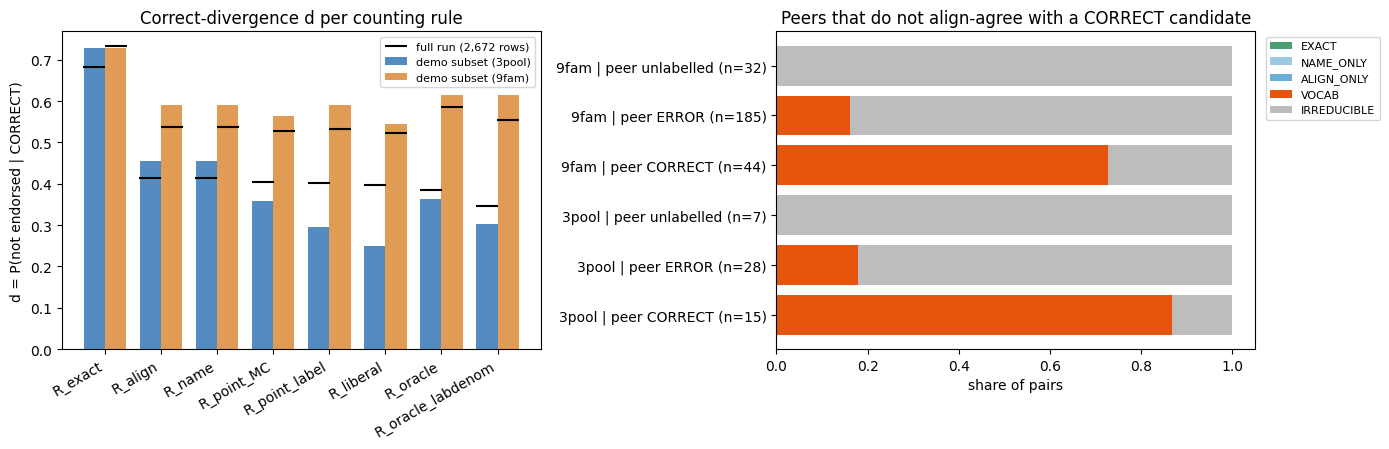

In [15]:
ref = meta["full_run_reference"]
order = ["R_exact", "R_align", "R_name", "R_point_MC", "R_point_label", "R_liberal", "R_oracle", "R_oracle_labdenom"]
res = []
for pool in ("3pool", "9fam"):
    H = A["pools"][pool]["heads"]
    for r in order:
        h = H[r]
        res.append({"pool": pool, "rule": r, "demo_e": h["e"], "demo_d": h["d"],
                    "demo_d_ci": "[%.3f, %.3f]" % tuple(h["d_ci"]) if None not in h["d_ci"] else "-",
                    "demo_AUROC_b": h["auroc_b"], "full_e": ref[pool]["heads"][r]["e"], "full_d": ref[pool]["heads"][r]["d"]})
R = pd.DataFrame(res)
pd.set_option("display.width", 160)
print(R.round(3).to_string(index=False))
print()
for pool in ("3pool", "9fam"):
    pr = A["pools"][pool]
    print(f"[{pool}] d_END_MAJ {pr['d_END_MAJ_this_pool']:.3f} | d_floor_pred (R_point_label) {pr['d_floor_pred']:.3f} "
          f"| bracket [{pr['d_bracket'][0]:.3f}, {pr['d_bracket'][1]:.3f}] | oracle {pr['d_R_oracle']:.3f} "
          f"| placebo ratio {pr['placebo']['specificity_ratio']:.2f} (full run {ref[pool]['specificity_ratio']:.2f}) "
          f"| AUROC c_vres {pr['c_vres']['R_AB']['auroc_c_vres']:.3f} vs c_score_align {pr['c_vres']['R_AB']['auroc_c_score_align_frozen']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(order))
for j, (pool, col) in enumerate((("3pool", "#2a6fb0"), ("9fam", "#d9822b"))):
    sub = R[R.pool == pool].set_index("rule").loc[order]
    ax[0].bar(x + (j - 0.5) * 0.38, sub.demo_d, 0.38, color=col, alpha=0.8, label=f"demo subset ({pool})")
    ax[0].scatter(x + (j - 0.5) * 0.38, sub.full_d, color="k", marker="_", s=260, zorder=3,
                  label="full run (2,672 rows)" if j == 0 else None)
ax[0].set_xticks(x, order, rotation=30, ha="right")
ax[0].set_ylabel("d = P(not endorsed | CORRECT)")
ax[0].set_title("Correct-divergence d per counting rule")
ax[0].legend(fontsize=8)
cls_order = ["EXACT", "NAME_ONLY", "ALIGN_ONLY", "VOCAB", "IRREDUCIBLE"]
dis = S[(S.pair_set == "disagreeing_CORRECT_cand_pairs")]
labels = []
mat = []
for pool in ("3pool", "9fam"):
    for pl in ("CORRECT", "ERROR", "unlabelled"):
        row = dis[(dis.pool == pool) & (dis.peer_label == pl)]
        if len(row):
            labels.append(f"{pool} | peer {pl} (n={int(row.n_pairs.iloc[0])})")
            mat.append([row[f"share_{c}"].iloc[0] for c in cls_order])
mat = np.array(mat)
cols = ["#4c9f70", "#9ecae1", "#6baed6", "#e6550d", "#bdbdbd"]
cum = np.zeros(len(mat))
for k, c in enumerate(cls_order):
    ax[1].barh(labels, mat[:, k], left=cum, color=cols[k], label=c)
    cum += mat[:, k]
ax[1].set_xlabel("share of pairs")
ax[1].set_title("Peers that do not align-agree with a CORRECT candidate")
ax[1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

**How to read this.** On the full run, adding the VOCAB checks moves **d** only a little: in the 3-pool, from 0.415
(END_MAJ, `R_align`) to a predicted floor of 0.402 (`R_point_label`), with a bracket of [0.396, 0.415]. Even the label
oracle leaves d at 0.385. Most of the peers that fail to endorse a CORRECT candidate are themselves labelled **ERROR**,
so shared vocabulary cannot remove this blind spot of consensus. The demo subset over-samples VOCAB pairs, so its
drops are larger than the full run's. The ordering exact ≥ align ≥ name ≥ point ≥ liberal holds by construction, and the
deterministic rules match the full run exactly for these rows.